# Machine Learning: Phân cụm Khách hàng (K-Means)
Sử dụng dữ liệu sạch để tạo cụm RFM.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

clean_path = '../data/cleaned/'
df_orders = pd.read_csv(f'{clean_path}orders.csv')
df_payments = pd.read_csv(f'{clean_path}payments.csv')
df_customers = pd.read_csv(f'{clean_path}customers.csv')

## 1. Tính toán ma trận RFM

In [2]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
max_date = df_orders['order_date'].max() + pd.Timedelta(days=1)

rfm = df_orders.groupby('customer_id').agg({
    'order_date': lambda x: (max_date - x.max()).days,
    'order_id': 'count'
}).rename(columns={'order_date': 'Recency', 'order_id': 'Frequency'})

monetary = df_payments.groupby('order_id')['amount'].sum().reset_index()
orders_monetary = df_orders.merge(monetary, on='order_id')
monetary_agg = orders_monetary.groupby('customer_id')['amount'].sum().reset_index()
monetary_agg.rename(columns={'amount': 'Monetary'}, inplace=True)

rfm = rfm.reset_index().merge(monetary_agg, on='customer_id', how='left').fillna(0)

## 2. K-Means Clustering

In [3]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Ánh xạ tên cụm cho dễ hiểu (ví dụ minh họa)
cluster_names = {0: 'At Risk', 1: 'Loyal', 2: 'New', 3: 'VIP'}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

display(rfm.head())

,customer_id,Recency,Frequency,Monetary,Cluster,Segment
0,1,131,5,38144,2,New
1,2,370,6,84928,3,VIP
2,3,258,6,57038,3,VIP
3,4,1076,2,25589,0,At Risk
4,5,3,4,43805,2,New


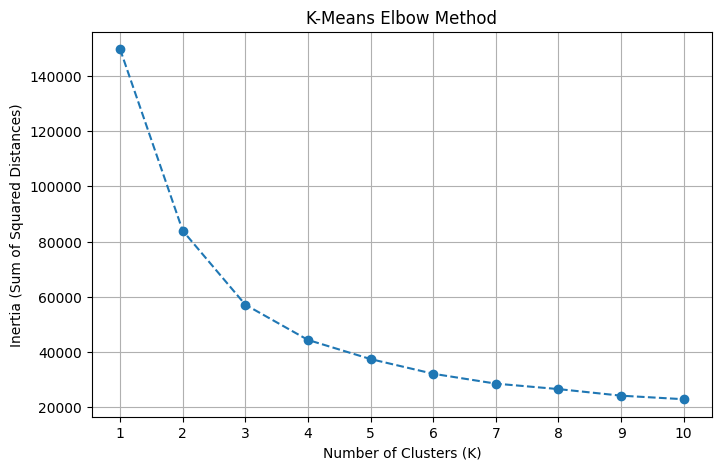

In [4]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)
plt.grid(True)
import os
os.makedirs('../report/img', exist_ok=True)
plt.savefig('../report/img/kmeans-elbow.png')
plt.show()

## 3. Lưu lại kết quả để dùng trong Power BI

In [5]:
if 'Segment' in df_customers.columns:
    df_customers = df_customers.drop(columns=['Segment'])
df_customers = df_customers.merge(rfm[['customer_id', 'Segment']], on='customer_id', how='left')
df_customers['Segment'] = df_customers['Segment'].fillna('Unknown')
df_customers.to_csv(f'{clean_path}customers.csv', index=False)
print('Đã gán nhãn phân khúc khách hàng và cập nhật customers.csv!')

Đã gán nhãn phân khúc khách hàng và cập nhật customers.csv!
